# Day 2 – Customer & Restaurant Segmentation

## Objective

Use unsupervised learning to identify hidden patterns among customers and restaurants.

### Techniques
- Feature Engineering
- Data Preprocessing
- StandardScaler
- K-Means
- DBSCAN
- Silhouette Score
- PCA
- Cluster Interpretation

In [60]:
import os

os.makedirs("data/processed", exist_ok=True)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# Load datasets

customers = pd.read_csv("../data/raw/customers.csv")
restaurants = pd.read_csv("../data/raw/restaurants.csv")
orders = pd.read_csv("../data/raw/orders.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")
reviews = pd.read_csv("../data/raw/reviews.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
payments = pd.read_csv("../data/raw/payments.csv")

print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Reviews:", reviews.shape)
print("Drivers:", drivers.shape)
print("Payments:", payments.shape)

Customers: (5000, 10)
Restaurants: (500, 10)
Orders: (50000, 13)
Deliveries: (50000, 11)
Reviews: (43996, 7)
Drivers: (1000, 10)
Payments: (50000, 7)


In [7]:
# Check the first few rows

customers.head()

,customer_id,age,gender,city,signup_date,customer_segment,avg_monthly_orders,preferred_cuisine,avg_order_value,payment_preference
0,10001,56,Female,Pune,2026-02-08,New,2.23,Desserts,261.32,UPI
1,10002,46,Other,Delhi,2026-06-11,Regular,4.15,Biryani,449.48,UPI
2,10003,32,Female,Chennai,2024-07-14,Regular,7.77,Burgers,386.41,Credit Card
3,10004,60,Male,Bangalore,2024-05-24,Regular,9.71,Desserts,474.21,Wallet
4,10005,25,Female,Hyderabad,2026-01-01,Regular,5.41,South Indian,477.06,Cash


In [8]:
# Check data types

customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   str    
 3   city                5000 non-null   str    
 4   signup_date         5000 non-null   str    
 5   customer_segment    5000 non-null   str    
 6   avg_monthly_orders  5000 non-null   float64
 7   preferred_cuisine   5000 non-null   str    
 8   avg_order_value     5000 non-null   float64
 9   payment_preference  5000 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 390.8 KB


In [9]:
# Check missing values

customers.isnull().sum()

customer_id           0
age                   0
gender                0
city                  0
signup_date           0
customer_segment      0
avg_monthly_orders    0
preferred_cuisine     0
avg_order_value       0
payment_preference    0
dtype: int64

In [10]:
# Convert date columns

orders["order_timestamp"] = pd.to_datetime(orders["order_timestamp"])
reviews["review_timestamp"] = pd.to_datetime(reviews["review_timestamp"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

print("Date conversion completed.")


Date conversion completed.


In [11]:
total_orders = (
    orders.groupby("customer_id")
    .size()
    .reset_index(name="total_orders")
)

total_orders.head()

,customer_id,total_orders
0,10001,15
1,10002,11
2,10003,5
3,10004,13
4,10005,11


In [12]:
avg_order_value = (
    orders.groupby("customer_id")["order_amount"]
    .mean()
    .reset_index(name="avg_order_value")
)

avg_order_value.head()

,customer_id,avg_order_value
0,10001,522.848667
1,10002,730.369091
2,10003,675.226000
3,10004,622.011538
4,10005,506.166364


In [13]:
total_spending = (
    orders.groupby("customer_id")["order_amount"]
    .sum()
    .reset_index(name="total_spending")
)

total_spending.head()

,customer_id,total_spending
0,10001,7842.73
1,10002,8034.06
2,10003,3376.13
3,10004,8086.15
4,10005,5567.83


In [14]:
# Calculate ordering frequency

start_date = orders["order_timestamp"].min()
end_date = orders["order_timestamp"].max()

observation_months = (
    (end_date.year - start_date.year) * 12
    + (end_date.month - start_date.month)
    + 1
)

ordering_frequency = (
    orders.groupby("customer_id")
    .size()
    .reset_index(name="ordering_frequency")
)

ordering_frequency["ordering_frequency"] = (
    ordering_frequency["ordering_frequency"] / observation_months
)

print("Observation period:", start_date, "to", end_date)
print("Observation months:", observation_months)

ordering_frequency.head()

Observation period: 2025-08-01 00:00:46 to 2026-07-31 23:57:32
Observation months: 12


,customer_id,ordering_frequency
0,10001,1.250000
1,10002,0.916667
2,10003,0.416667
3,10004,1.083333
4,10005,0.916667


In [15]:
# Average rating given by each customer

avg_rating_given = (
    reviews.groupby("customer_id")["rating"]
    .mean()
    .reset_index(name="avg_rating_given")
)

avg_rating_given.head()

,customer_id,avg_rating_given
0,10001,3.800000
1,10002,3.625000
2,10003,4.666667
3,10004,3.545455
4,10005,3.100000


In [16]:
# Number of orders placed on weekends

weekend_orders = (
    orders[orders["is_weekend"] == True]
    .groupby("customer_id")
    .size()
    .reset_index(name="weekend_orders")
)

weekend_orders.head()

,customer_id,weekend_orders
0,10001,9
1,10002,5
2,10003,1
3,10004,5
4,10005,3


In [18]:
# Extract order hour

orders["order_hour"] = orders["order_timestamp"].dt.hour

# Count late-night orders

late_night_orders = (
    orders[
        (orders["order_hour"] >= 22) |
        (orders["order_hour"] < 4)
    ]
    .groupby("customer_id")
    .size()
    .reset_index(name="late_night_orders")
)

late_night_orders.head()

,customer_id,late_night_orders
0,10001,5
1,10002,4
2,10004,4
3,10005,5
4,10006,1


In [19]:
customer_features = total_orders.merge(
    avg_order_value,
    on="customer_id",
    how="left"
)

customer_features = customer_features.merge(
    total_spending,
    on="customer_id",
    how="left"
)

customer_features = customer_features.merge(
    ordering_frequency,
    on="customer_id",
    how="left"
)

customer_features = customer_features.merge(
    avg_rating_given,
    on="customer_id",
    how="left"
)

customer_features = customer_features.merge(
    weekend_orders,
    on="customer_id",
    how="left"
)

customer_features = customer_features.merge(
    late_night_orders,
    on="customer_id",
    how="left"
)

customer_features.head()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
0,10001,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0
1,10002,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0
2,10003,5,675.226000,3376.13,0.416667,4.666667,1.0,NaN
3,10004,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0
4,10005,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0


In [20]:
print("Shape:", customer_features.shape)

print("\nColumns:")
print(customer_features.columns.tolist())

Shape: (5000, 8)

Columns:
['customer_id', 'total_orders', 'avg_order_value', 'total_spending', 'ordering_frequency', 'avg_rating_given', 'weekend_orders', 'late_night_orders']


In [21]:
customer_features.isnull().sum()

customer_id             0
total_orders            0
avg_order_value         0
total_spending          0
ordering_frequency      0
avg_rating_given        0
weekend_orders        314
late_night_orders     418
dtype: int64

In [22]:
customer_features["weekend_orders"] = (
    customer_features["weekend_orders"].fillna(0)
)

customer_features["late_night_orders"] = (
    customer_features["late_night_orders"].fillna(0)
)

In [23]:
customer_features["avg_rating_given"] = (
    customer_features["avg_rating_given"]
    .fillna(reviews["rating"].mean())
)

In [24]:
print(customer_features.isnull().sum())

customer_id           0
total_orders          0
avg_order_value       0
total_spending        0
ordering_frequency    0
avg_rating_given      0
weekend_orders        0
late_night_orders     0
dtype: int64


In [25]:
customer_features.describe()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,10.000000,687.881271,6877.948296,0.833333,3.873064,2.844000,2.510000
std,1443.520003,3.117811,140.404224,2527.200294,0.259818,0.413879,1.718911,1.582151
min,10001.000000,1.000000,225.602000,525.710000,0.083333,1.000000,0.000000,0.000000
25%,11250.750000,8.000000,591.405091,5066.015000,0.666667,3.625000,2.000000,1.000000
50%,12500.500000,10.000000,679.497832,6701.945000,0.833333,3.888889,3.000000,2.000000
75%,13750.250000,12.000000,774.346595,8440.917500,1.000000,4.154858,4.000000,3.000000
max,15000.000000,23.000000,1379.712500,18783.240000,1.916667,5.000000,10.000000,9.000000


In [26]:
# Select features for clustering

features = [
    "total_orders",
    "avg_order_value",
    "total_spending",
    "ordering_frequency",
    "avg_rating_given",
    "weekend_orders",
    "late_night_orders"
]

X = customer_features[features].copy()

X.head()

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
0,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0
1,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0
2,5,675.226000,3376.13,0.416667,4.666667,1.0,0.0
3,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0
4,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0


In [27]:
print("Shape of X:", X.shape)
print("Columns:", X.columns.tolist())

Shape of X: (5000, 7)
Columns: ['total_orders', 'avg_order_value', 'total_spending', 'ordering_frequency', 'avg_rating_given', 'weekend_orders', 'late_night_orders']


In [28]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.60384975, -1.1755281 ,  0.38179728,  1.60384975, -0.17655131,
         3.5816955 ,  1.57396456],
       [ 0.32076995,  0.30264096,  0.45751314,  0.32076995, -0.59942222,
         1.25440798,  0.94185028],
       [-1.60384975, -0.09014356, -1.38578986, -1.60384975,  1.91766656,
        -1.07287955, -1.58660685],
       [ 0.96230985, -0.46919045,  0.47812694,  0.96230985, -0.79163627,
         1.25440798,  0.94185028],
       [ 0.32076995, -1.29435623, -0.51845884,  0.32076995, -1.86803496,
         0.09076421,  1.57396456]])

In [29]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.describe()

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.421085e-18,-1.492140e-16,-1.882938e-16,-1.534772e-16,-6.210144e-16,7.958079e-17,1.421085e-16
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-2.886930e+00,-3.292818e+00,-2.513799e+00,-2.886930e+00,-6.942486e+00,-1.654701e+00,-1.586607e+00
25%,-6.415399e-01,-6.872003e-01,-7.170443e-01,-6.415399e-01,-5.994222e-01,-4.910577e-01,-9.544926e-01
50%,0.000000e+00,-5.971528e-02,-6.965055e-02,0.000000e+00,3.824027e-02,9.076421e-02,-3.223783e-01
75%,6.415399e-01,6.158930e-01,6.185206e-01,6.415399e-01,6.809301e-01,6.725861e-01,3.097360e-01
max,4.170009e+00,4.927917e+00,4.711333e+00,4.170009e+00,2.723135e+00,4.163517e+00,4.102422e+00


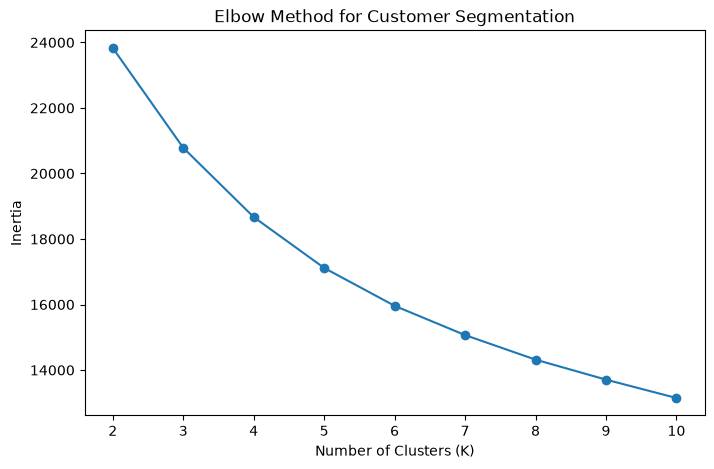

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.show()

In [31]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

{2: 0.26749928310051685,
 3: 0.1807016510280509,
 4: 0.1748989940663269,
 5: 0.17000854346015504,
 6: 0.1638058246921856,
 7: 0.15973083941747823,
 8: 0.15113902029404852,
 9: 0.14910367969498325,
 10: 0.1513762403066082}

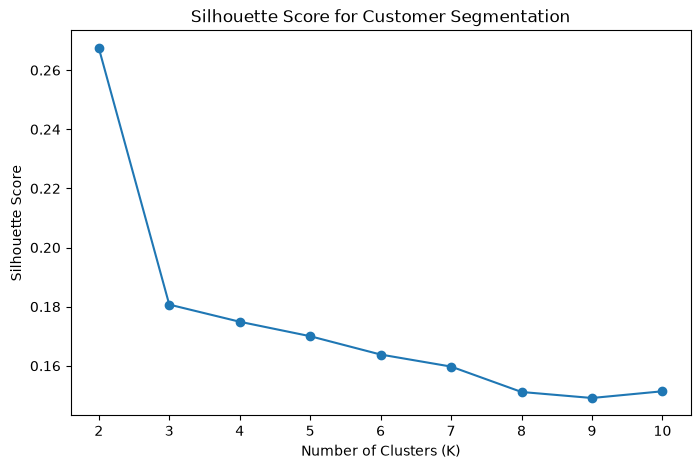

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Customer Segmentation")
plt.show()

In [33]:
# Final K-Means model

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = kmeans.fit_predict(X_scaled)

customer_features.head()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders,cluster
0,10001,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0,1
1,10002,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0,1
2,10003,5,675.226000,3376.13,0.416667,4.666667,1.0,0.0,0
3,10004,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0,1
4,10005,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0,1


In [34]:
customer_features["cluster"].value_counts().sort_index()

cluster
0    2766
1    2234
Name: count, dtype: int64

In [35]:
cluster_profile = customer_features.groupby("cluster").agg({
    "total_orders": "mean",
    "avg_order_value": "mean",
    "total_spending": "mean",
    "ordering_frequency": "mean",
    "avg_rating_given": "mean",
    "weekend_orders": "mean",
    "late_night_orders": "mean"
}).round(2)

cluster_profile

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
cluster,,,,,,,
0,7.84,671.86,5231.67,0.65,3.87,2.05,1.81
1,12.67,707.72,8916.27,1.06,3.87,3.83,3.37


In [36]:
cluster_names = {
    0: "Occasional Moderate-Value Customers",
    1: "Frequent High-Value Customers"
}

customer_features["cluster_name"] = customer_features["cluster"].map(cluster_names)

customer_features.head()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders,cluster,cluster_name
0,10001,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0,1,Frequent High-Value Customers
1,10002,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0,1,Frequent High-Value Customers
2,10003,5,675.226000,3376.13,0.416667,4.666667,1.0,0.0,0,Occasional Moderate-Value Customers
3,10004,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0,1,Frequent High-Value Customers
4,10005,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0,1,Frequent High-Value Customers


In [37]:
customer_features["cluster_name"].value_counts()

cluster_name
Occasional Moderate-Value Customers    2766
Frequent High-Value Customers          2234
Name: count, dtype: int64

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = customer_features["cluster"]

pca_df.head()

,PC1,PC2,cluster
0,3.483080,-2.218389,1
1,1.322859,-0.077106,1
2,-3.207581,0.415756,0
3,1.915535,-0.916928,1
4,0.492576,-1.815656,1


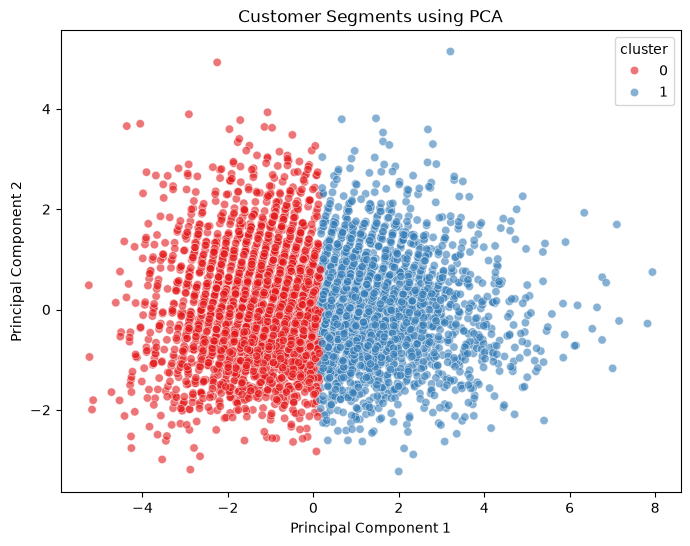

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.6
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [40]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

customer_features["dbscan_cluster"] = dbscan_labels

customer_features["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     164
 0    4836
Name: count, dtype: int64

In [41]:
dbscan_cluster_count = (
    customer_features["dbscan_cluster"]
    .loc[customer_features["dbscan_cluster"] != -1]
    .nunique()
)

noise_count = (
    customer_features["dbscan_cluster"] == -1
).sum()

print("Number of DBSCAN clusters:", dbscan_cluster_count)
print("Number of noise points:", noise_count)
print(
    "Noise percentage:",
    round(noise_count / len(customer_features) * 100, 2),
    "%"
)

Number of DBSCAN clusters: 1
Number of noise points: 164
Noise percentage: 3.28 %


In [42]:
# Try different eps values

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(
        f"eps={eps} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise} | "
        f"noise%={n_noise / len(labels) * 100:.2f}%"
    )

eps=0.3 | clusters=0 | noise=5000 | noise%=100.00%
eps=0.4 | clusters=0 | noise=5000 | noise%=100.00%
eps=0.5 | clusters=1 | noise=4990 | noise%=99.80%
eps=0.6 | clusters=15 | noise=4169 | noise%=83.38%
eps=0.7 | clusters=6 | noise=2508 | noise%=50.16%
eps=0.8 | clusters=1 | noise=1551 | noise%=31.02%
eps=1.0 | clusters=1 | noise=490 | noise%=9.80%


In [43]:
for min_samples in [5, 10, 15, 20]:

    print(f"\nmin_samples = {min_samples}")

    for eps in [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels) * 100

        print(
            f"eps={eps:.2f} | "
            f"clusters={n_clusters} | "
            f"noise={n_noise} | "
            f"noise%={noise_pct:.2f}%"
        )


min_samples = 5
eps=0.70 | clusters=14 | noise=1562 | noise%=31.24%
eps=0.75 | clusters=12 | noise=1231 | noise%=24.62%
eps=0.80 | clusters=12 | noise=958 | noise%=19.16%
eps=0.85 | clusters=4 | noise=699 | noise%=13.98%
eps=0.90 | clusters=2 | noise=503 | noise%=10.06%
eps=0.95 | clusters=3 | noise=384 | noise%=7.68%
eps=1.00 | clusters=3 | noise=294 | noise%=5.88%

min_samples = 10
eps=0.70 | clusters=6 | noise=2508 | noise%=50.16%
eps=0.75 | clusters=3 | noise=1980 | noise%=39.60%
eps=0.80 | clusters=1 | noise=1551 | noise%=31.02%
eps=0.85 | clusters=2 | noise=1171 | noise%=23.42%
eps=0.90 | clusters=1 | noise=828 | noise%=16.56%
eps=0.95 | clusters=1 | noise=633 | noise%=12.66%
eps=1.00 | clusters=1 | noise=490 | noise%=9.80%

min_samples = 15
eps=0.70 | clusters=3 | noise=3295 | noise%=65.90%
eps=0.75 | clusters=2 | noise=2626 | noise%=52.52%
eps=0.80 | clusters=1 | noise=2058 | noise%=41.16%
eps=0.85 | clusters=1 | noise=1498 | noise%=29.96%
eps=0.90 | clusters=1 | noise=1100 | 

In [45]:
# Final DBSCAN Model

dbscan = DBSCAN(
    eps=1.00,
    min_samples=5
)

customer_features["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

customer_features["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     294
 0    4697
 1       4
 2       5
Name: count, dtype: int64

In [46]:
noise_count = (customer_features["dbscan_cluster"] == -1).sum()

noise_percentage = (
    noise_count / len(customer_features)
) * 100

print("Noise points:", noise_count)
print("Noise percentage:", round(noise_percentage, 2), "%")

Noise points: 294
Noise percentage: 5.88 %


In [47]:
cluster_counts = (
    customer_features["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

dbscan_cluster
-1     294
 0    4697
 1       4
 2       5
Name: count, dtype: int64

In [48]:
dbscan_profile = (
    customer_features
    .groupby("dbscan_cluster")[
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

dbscan_profile

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
dbscan_cluster,,,,,,,
-1,11.38,750.77,8410.17,0.95,3.65,3.88,3.31
0,9.91,683.67,6776.85,0.83,3.89,2.78,2.46
1,18.00,523.12,9416.13,1.50,3.96,3.75,5.00
2,9.00,1082.29,9729.27,0.75,4.25,3.20,3.00


In [50]:
# PCA for visualization

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", pca_result.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original dimensions: 7
PCA dimensions: 2
Explained variance ratio: [0.49985462 0.17174094]
Total explained variance: 0.6715955671846309


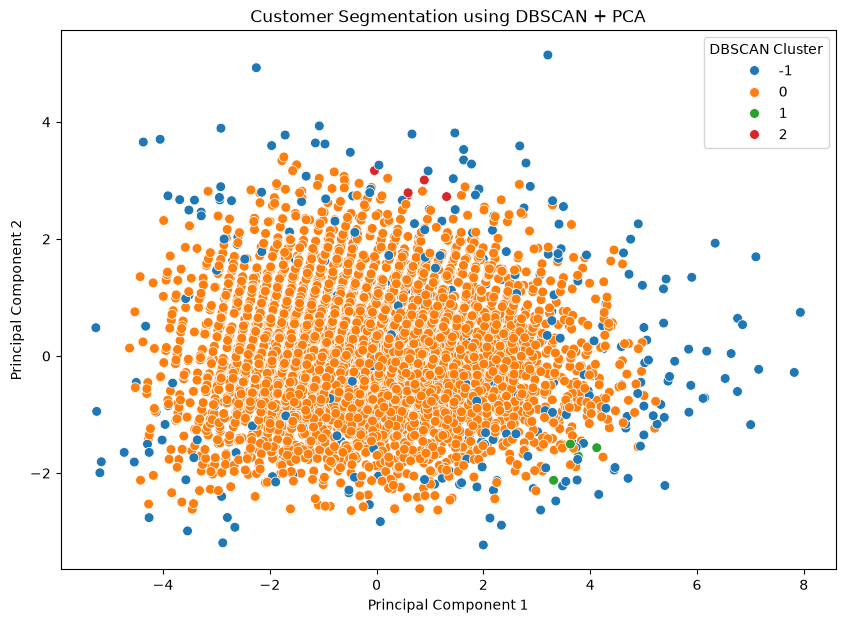

In [51]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=customer_features["dbscan_cluster"],
    palette="tab10",
    s=50
)

plt.title("Customer Segmentation using DBSCAN + PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster")

plt.show()

In [52]:
dbscan_profile = (
    customer_features
    .groupby("dbscan_cluster")[
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

dbscan_profile

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
dbscan_cluster,,,,,,,
-1,11.38,750.77,8410.17,0.95,3.65,3.88,3.31
0,9.91,683.67,6776.85,0.83,3.89,2.78,2.46
1,18.00,523.12,9416.13,1.50,3.96,3.75,5.00
2,9.00,1082.29,9729.27,0.75,4.25,3.20,3.00


In [53]:
customer_features["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     294
 0    4697
 1       4
 2       5
Name: count, dtype: int64

In [54]:
customer_segmentation = customer_features.copy()

customer_segmentation["kmeans_cluster"] = kmeans.labels_
customer_segmentation["dbscan_cluster"] = dbscan.labels_

customer_segmentation.head()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders,cluster,cluster_name,dbscan_cluster,kmeans_cluster
0,10001,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0,1,Frequent High-Value Customers,-1,1
1,10002,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0,1,Frequent High-Value Customers,0,1
2,10003,5,675.226000,3376.13,0.416667,4.666667,1.0,0.0,0,Occasional Moderate-Value Customers,0,0
3,10004,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0,1,Frequent High-Value Customers,0,1
4,10005,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0,1,Frequent High-Value Customers,0,1


In [55]:
customer_segmentation.shape

(5000, 12)

In [56]:
kmeans_profile = (
    customer_segmentation
    .groupby("kmeans_cluster")
    [
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

kmeans_profile

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
kmeans_cluster,,,,,,,
0,7.84,671.86,5231.67,0.65,3.87,2.05,1.81
1,12.67,707.72,8916.27,1.06,3.87,3.83,3.37


In [57]:
cluster_names = {
    0: "Occasional Budget Customers",
    1: "Frequent High-Value Customers"
}

customer_segmentation["customer_segment_name"] = (
    customer_segmentation["kmeans_cluster"]
    .map(cluster_names)
)

customer_segmentation.head()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders,cluster,cluster_name,dbscan_cluster,kmeans_cluster,customer_segment_name
0,10001,15,522.848667,7842.73,1.250000,3.800000,9.0,5.0,1,Frequent High-Value Customers,-1,1,Frequent High-Value Customers
1,10002,11,730.369091,8034.06,0.916667,3.625000,5.0,4.0,1,Frequent High-Value Customers,0,1,Frequent High-Value Customers
2,10003,5,675.226000,3376.13,0.416667,4.666667,1.0,0.0,0,Occasional Moderate-Value Customers,0,0,Occasional Budget Customers
3,10004,13,622.011538,8086.15,1.083333,3.545455,5.0,4.0,1,Frequent High-Value Customers,0,1,Frequent High-Value Customers
4,10005,11,506.166364,5567.83,0.916667,3.100000,3.0,5.0,1,Frequent High-Value Customers,0,1,Frequent High-Value Customers


In [62]:
import os

os.makedirs("data/processed", exist_ok=True)

customer_features.to_csv(
    "data/processed/customer_features.csv",
    index=False
)

print("Customer features saved successfully!")

Customer features saved successfully!


In [63]:
import os

print("Notebook working directory:")
print(os.getcwd())

print("\nFiles in data/processed:")
print(os.listdir("data/processed"))

Notebook working directory:
/home/nineleaps/ML_CAPSTONE_PROJECT/Uber-Eats-ML-Project/notebooks

Files in data/processed:
['customer_segmentation.csv', 'customer_features.csv']
